<a href="https://colab.research.google.com/github/akashvgeorge/ICT_DSA_26/blob/main/preprocessing_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [350]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

## Reading data

In [289]:
housing_df = pd.read_csv("/content/House_Pricing.csv")

## Data Overview

In [290]:
housing_df.head(2)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639


In [291]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [292]:
housing_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## Handling Duplicates

In [293]:
housing_df.duplicated().sum()

np.int64(0)

In [294]:
housing_df.columns.duplicated()

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [295]:
num_cols = housing_df.select_dtypes(include=['number']).columns
cat_cols = housing_df.select_dtypes(include=['object']).columns

## Handling missing values

In [296]:
housing_df.isna()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21609,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21610,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21611,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [297]:
housing_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [298]:
housing_df.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [299]:
missing_percent = housing_df.isna().sum()/len(housing_df)*100
sorted = missing_percent.sort_values(ascending=True)
sorted

,0
ID,0.000000
Date House was Sold,0.000000
No of Bedrooms,0.000000
No of Floors,0.000000
Basement Area (in Sqft),0.000000
Overall Grade,0.000000
Condition of the House,0.000000
Waterfront View,0.000000
Renovated Year,0.000000
Age of House (in Years),0.000000


In [300]:
num_cols

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [301]:
len(num_cols)

17

In [302]:
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

In [303]:
len(cat_cols)

4

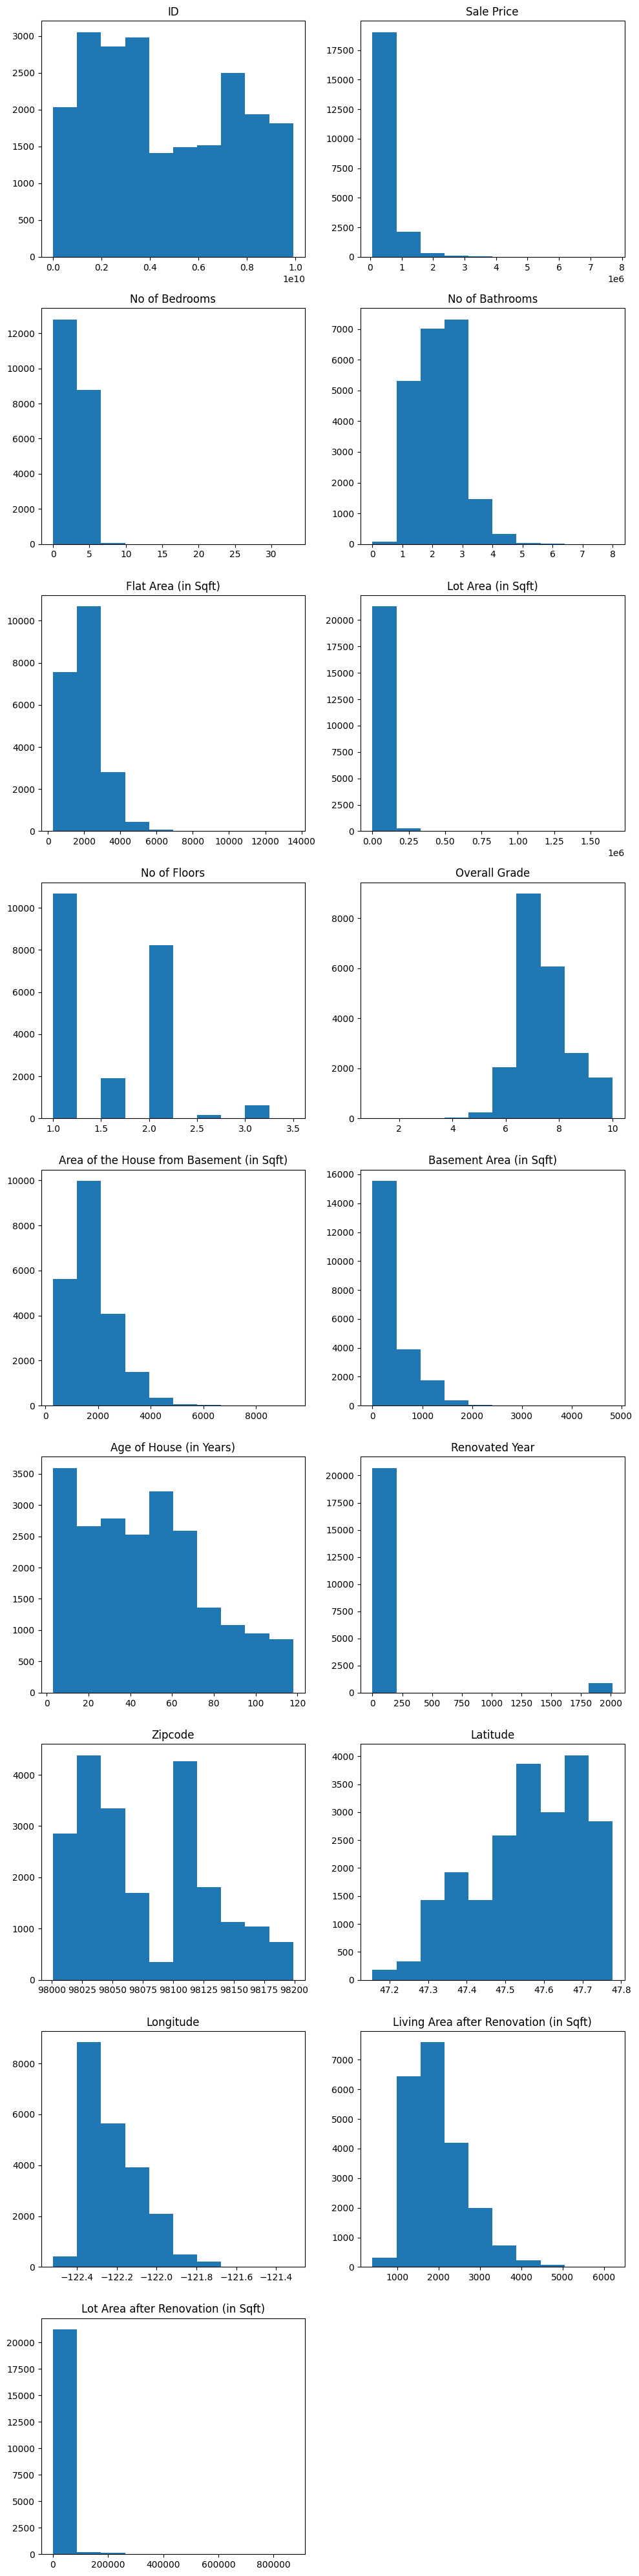

In [304]:
plt.figure(figsize = (10, 40))
for i, col in enumerate(num_cols,1):
  plt.subplot(9,2,i)
  plt.hist(housing_df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

In [305]:
cols = ['Zipcode', 'Latitude', 'Longitude', 'Living Area after Renovation (in Sqft)', 'Area of the House from Basement (in Sqft)',\
        'Sale Price', 'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)']

In [306]:
housing_df = housing_df.fillna(housing_df[cols].median())

In [307]:
housing_df[cols].dtypes

,0
Zipcode,float64
Latitude,float64
Longitude,float64
Living Area after Renovation (in Sqft),float64
Area of the House from Basement (in Sqft),float64
Sale Price,float64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64


In [308]:
housing_df.drop('No of Times Visited', axis = 1, inplace=True)  # Dropping the column as 90% of data is NA

In [309]:
# Filling with median values as most of the columns are skewed
housing_df = housing_df.fillna(housing_df[cols].median())

In [310]:
housing_df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [311]:
housing_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.401817e+05,3.370842,2.114757,2079.861010,1.510464e+04,1.494309,7.623467,1788.312497,291.509045,46.994864,84.402258,98077.937167,47.560048,-122.213892,1986.532133,12768.455652
std,2.876566e+09,3.673570e+05,0.930062,0.770069,918.302876,4.141992e+04,0.539989,1.105439,827.929506,442.575043,29.373411,401.679240,53.504259,0.138562,0.140827,685.389122,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.220000e+05,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [312]:
cat_cols.isna().sum()

np.int64(0)

In [313]:
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

In [314]:
housing_df[num_cols].dtypes

,0
ID,int64
Sale Price,float64
No of Bedrooms,int64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Overall Grade,int64
Area of the House from Basement (in Sqft),float64
Basement Area (in Sqft),int64


In [315]:
housing_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


## Handling outliers

In [316]:
numerical_cols = ['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)']

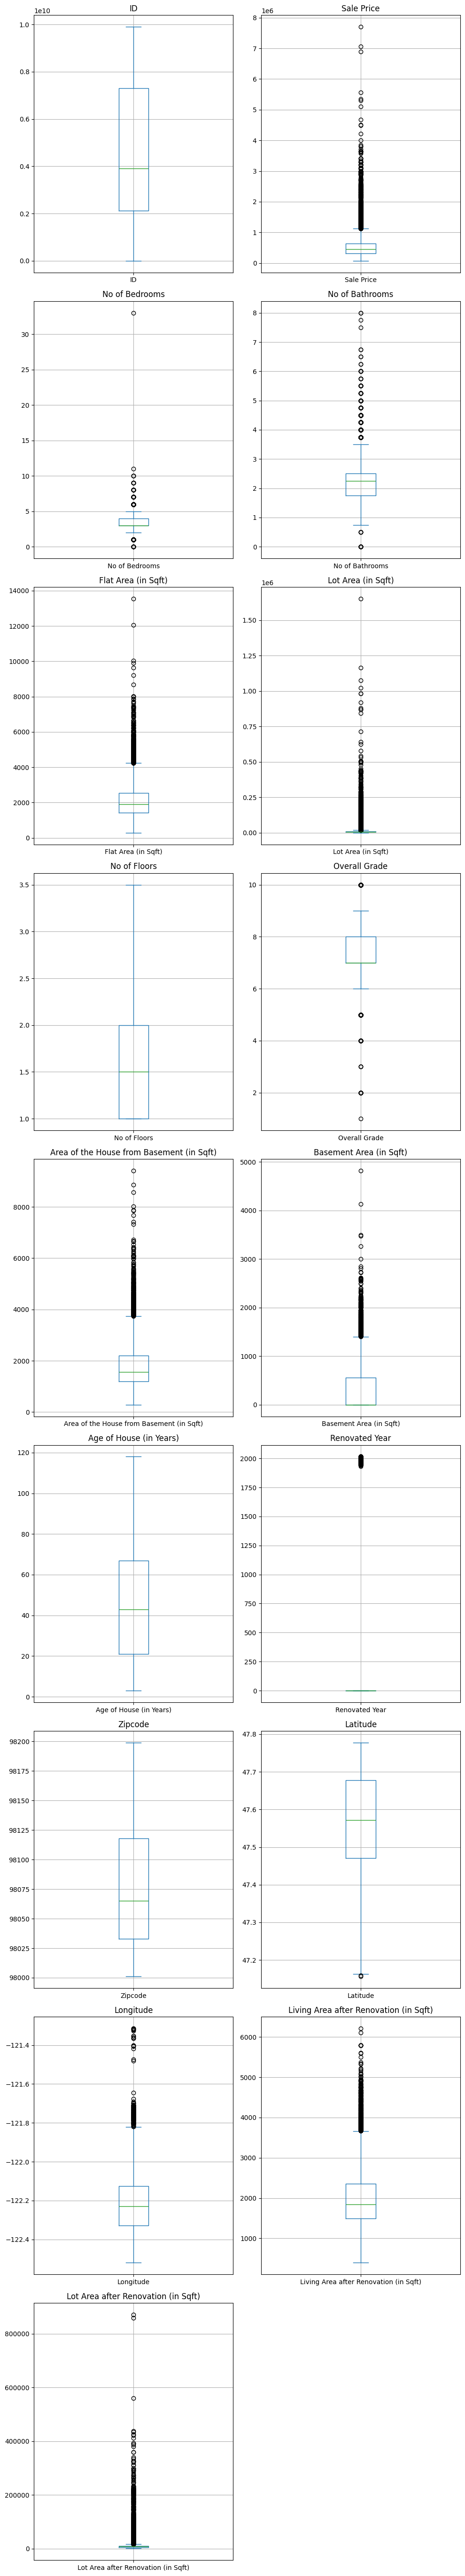

In [317]:
plt.figure(figsize=(10,55))
for i, col in enumerate(numerical_cols,1):
  plt.subplot(9,2,i)
  housing_df[col].plot(kind = 'box')
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [318]:
Q1 = housing_df[numerical_cols].quantile(0.25)
Q3 = housing_df[numerical_cols].quantile(0.75)
IQR = Q3-Q1


upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

outliers = ((housing_df[numerical_cols] > upper_limit) | (housing_df[numerical_cols] < lower_limit)).any(axis=1)

outliers_df = housing_df[outliers]

outlier_percentage = len(outliers_df) * 100/ len(housing_df)

print("percentage fo outliers in the dataframe :", outlier_percentage)

percentage fo outliers in the dataframe : 26.433165224633324


In [319]:
outlier_counts = ((housing_df[numerical_cols] > upper_limit) |
                  (housing_df[numerical_cols] < lower_limit)).mean()*100

print(outlier_counts.sort_values(ascending=False))

Lot Area (in Sqft)                           11.210845
Lot Area after Renovation (in Sqft)          10.151298
Overall Grade                                 8.841901
Sale Price                                    5.362513
Renovated Year                                4.228936
Area of the House from Basement (in Sqft)     2.822375
Flat Area (in Sqft)                           2.646555
No of Bathrooms                               2.641928
No of Bedrooms                                2.526257
Living Area after Renovation (in Sqft)        2.517004
Basement Area (in Sqft)                       2.294915
Longitude                                     1.184472
Latitude                                      0.009254
ID                                            0.000000
No of Floors                                  0.000000
Zipcode                                       0.000000
Age of House (in Years)                       0.000000
dtype: float64


In [320]:
clip_cols = ['Lot Area (in Sqft)', 'Lot Area after Renovation (in Sqft)', 'Overall Grade', 'Renovated Year']
housing_df[clip_cols] = housing_df[clip_cols].clip(lower_limit, upper_limit, axis=1)

In [321]:
remove_cols = ['Area of the House from Basement (in Sqft)',
'Flat Area (in Sqft)',
'No of Bathrooms',
'No of Bedrooms',
'Living Area after Renovation (in Sqft)',
'Basement Area (in Sqft)',
'Longitude',
'Latitude']

In [322]:
remove_mask = (
    (housing_df[remove_cols] > upper_limit[remove_cols]) |
    (housing_df[remove_cols] < lower_limit[remove_cols])
).any(axis=1)

housing_df = housing_df[~remove_mask]

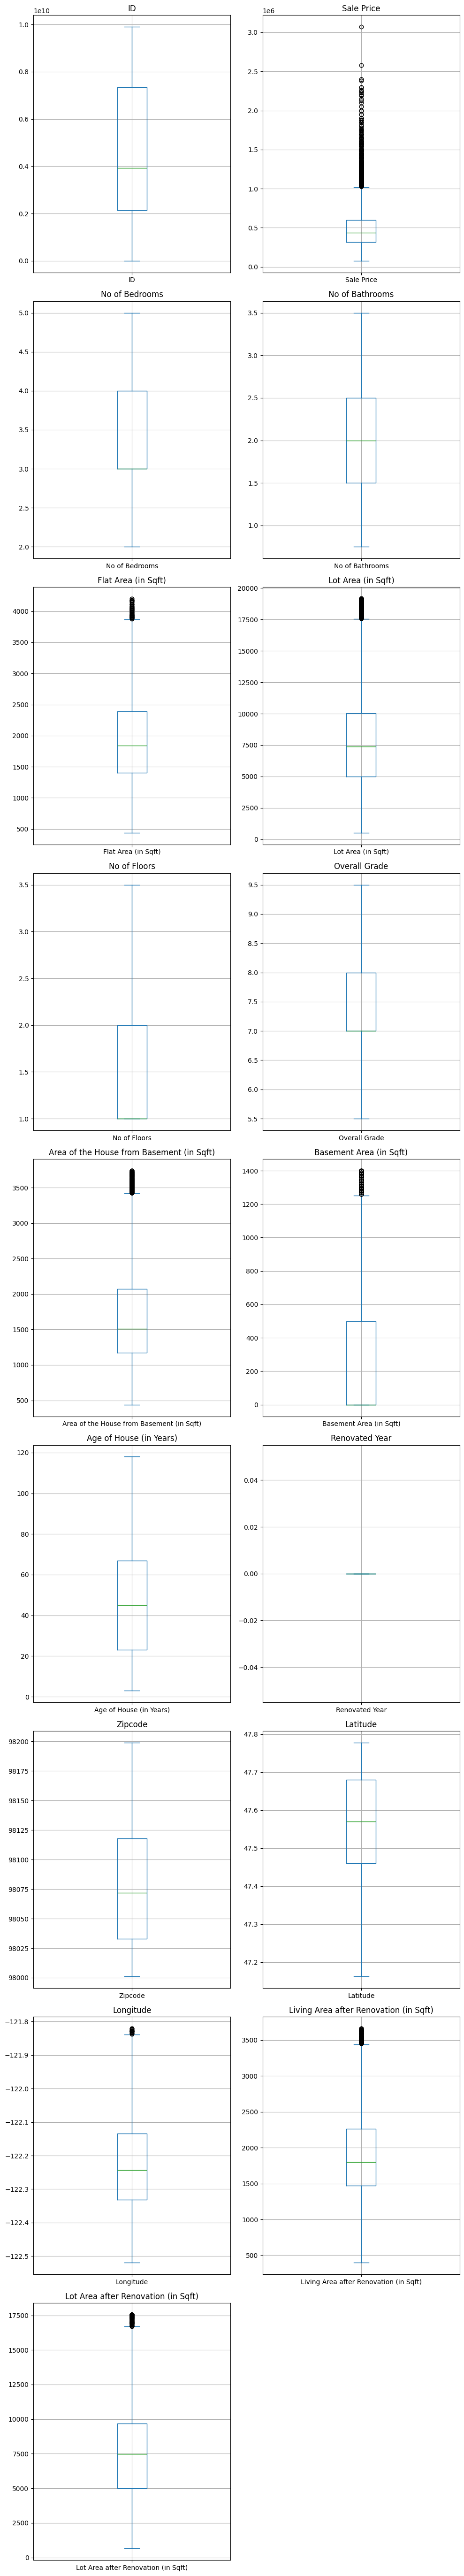

In [323]:
plt.figure(figsize=(10,55))
for i, col in enumerate(numerical_cols,1):
  plt.subplot(9,2,i)
  housing_df[col].plot(kind = 'box')
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [324]:
housing_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,1.942700e+04,1.942700e+04,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.0,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000
mean,4.610704e+09,4.876620e+05,3.292582,2.022263,1929.445411,8290.770217,1.477248,7.504195,1676.574922,252.953724,47.681989,0.0,98079.390590,47.558171,-122.222670,1899.710094,7951.615072
std,2.870841e+09,2.473135e+05,0.780006,0.661564,690.790099,4815.122235,0.539324,0.928209,663.841464,376.374594,29.303992,0.0,53.663534,0.141462,0.130499,571.803753,4166.674890
min,1.200019e+06,7.800000e+04,2.000000,0.750000,440.000000,520.000000,1.000000,5.500000,440.000000,0.000000,3.000000,0.0,98001.000000,47.162200,-122.519000,399.000000,651.000000
25%,2.146050e+09,3.150000e+05,3.000000,1.500000,1400.000000,5000.000000,1.000000,7.000000,1170.000000,0.000000,23.000000,0.0,98033.000000,47.459900,-122.332000,1470.000000,5000.000000
50%,3.920000e+09,4.350000e+05,3.000000,2.000000,1840.000000,7392.000000,1.000000,7.000000,1510.000000,0.000000,45.000000,0.0,98072.000000,47.570700,-122.244000,1800.000000,7480.000000
75%,7.338000e+09,6.000000e+05,4.000000,2.500000,2390.000000,10030.500000,2.000000,8.000000,2070.000000,500.000000,67.000000,0.0,98118.000000,47.680050,-122.134000,2260.000000,9685.000000
max,9.900000e+09,3.070000e+06,5.000000,3.500000,4200.000000,19152.500000,3.500000,9.500000,3740.000000,1400.000000,118.000000,0.0,98199.000000,47.777600,-121.821000,3660.000000,17557.500000


In [325]:
housing_df['Renovated Year'].nunique()

1

## Removing unwanted column

In [326]:
# corelation
corr_matrix = housing_df[numerical_cols].corr(method='pearson')
corr_matrix

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
ID,1.000000,0.007526,0.013782,0.035375,0.018543,-0.126365,0.033199,0.037655,0.020877,-0.002301,-0.031505,NaN,-0.008012,0.005263,0.020678,0.015968,-0.124757
Sale Price,0.007526,1.000000,0.253861,0.404845,0.588627,0.061359,0.253866,0.597710,0.483430,0.228195,0.004883,NaN,0.007386,0.398856,0.012943,0.516530,0.060657
No of Bedrooms,0.013782,0.253861,1.000000,0.463445,0.583948,0.156361,0.155202,0.316799,0.468327,0.246330,-0.158798,NaN,-0.161464,-0.042764,0.168984,0.385658,0.153332
No of Bathrooms,0.035375,0.404845,0.463445,1.000000,0.693427,0.013553,0.514971,0.613315,0.610208,0.196890,-0.546980,NaN,-0.204413,-0.007343,0.253799,0.508089,0.013974
Flat Area (in Sqft),0.018543,0.588627,0.583948,0.693427,1.000000,0.262477,0.349818,0.693457,0.845968,0.343215,-0.328076,NaN,-0.194484,0.020672,0.278508,0.726924,0.255454
Lot Area (in Sqft),-0.126365,0.061359,0.156361,0.013553,0.262477,1.000000,-0.253882,0.109513,0.243434,0.053024,0.007652,NaN,-0.266297,-0.140236,0.329919,0.331800,0.907658
No of Floors,0.033199,0.253866,0.155202,0.514971,0.349818,-0.253882,1.000000,0.469123,0.531009,-0.294279,-0.498318,NaN,-0.052292,0.041612,0.122651,0.254150,-0.256432
Overall Grade,0.037655,0.597710,0.316799,0.613315,0.693457,0.109513,0.469123,1.000000,0.690333,0.056039,-0.466886,NaN,-0.170360,0.100491,0.209709,0.645637,0.119744
Area of the House from Basement (in Sqft),0.020877,0.483430,0.468327,0.610208,0.845968,0.243434,0.531009,0.690333,1.000000,-0.209854,-0.442731,NaN,-0.271089,-0.043976,0.390757,0.699477,0.239159
Basement Area (in Sqft),-0.002301,0.228195,0.246330,0.196890,0.343215,0.053024,-0.294279,0.056039,-0.209854,1.000000,0.178700,NaN,0.121075,0.115672,-0.177747,0.101599,0.047723


In [327]:
# Column "Renovated Year" has no information, so dropping it
housing_df.drop('Renovated Year', axis=1, inplace=True)

In [328]:
numerical_cols.remove('Renovated Year')

In [329]:
corr_matrix = housing_df[numerical_cols].corr(method='pearson')
corr_matrix

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
ID,1.000000,0.007526,0.013782,0.035375,0.018543,-0.126365,0.033199,0.037655,0.020877,-0.002301,-0.031505,-0.008012,0.005263,0.020678,0.015968,-0.124757
Sale Price,0.007526,1.000000,0.253861,0.404845,0.588627,0.061359,0.253866,0.597710,0.483430,0.228195,0.004883,0.007386,0.398856,0.012943,0.516530,0.060657
No of Bedrooms,0.013782,0.253861,1.000000,0.463445,0.583948,0.156361,0.155202,0.316799,0.468327,0.246330,-0.158798,-0.161464,-0.042764,0.168984,0.385658,0.153332
No of Bathrooms,0.035375,0.404845,0.463445,1.000000,0.693427,0.013553,0.514971,0.613315,0.610208,0.196890,-0.546980,-0.204413,-0.007343,0.253799,0.508089,0.013974
Flat Area (in Sqft),0.018543,0.588627,0.583948,0.693427,1.000000,0.262477,0.349818,0.693457,0.845968,0.343215,-0.328076,-0.194484,0.020672,0.278508,0.726924,0.255454
Lot Area (in Sqft),-0.126365,0.061359,0.156361,0.013553,0.262477,1.000000,-0.253882,0.109513,0.243434,0.053024,0.007652,-0.266297,-0.140236,0.329919,0.331800,0.907658
No of Floors,0.033199,0.253866,0.155202,0.514971,0.349818,-0.253882,1.000000,0.469123,0.531009,-0.294279,-0.498318,-0.052292,0.041612,0.122651,0.254150,-0.256432
Overall Grade,0.037655,0.597710,0.316799,0.613315,0.693457,0.109513,0.469123,1.000000,0.690333,0.056039,-0.466886,-0.170360,0.100491,0.209709,0.645637,0.119744
Area of the House from Basement (in Sqft),0.020877,0.483430,0.468327,0.610208,0.845968,0.243434,0.531009,0.690333,1.000000,-0.209854,-0.442731,-0.271089,-0.043976,0.390757,0.699477,0.239159
Basement Area (in Sqft),-0.002301,0.228195,0.246330,0.196890,0.343215,0.053024,-0.294279,0.056039,-0.209854,1.000000,0.178700,0.121075,0.115672,-0.177747,0.101599,0.047723


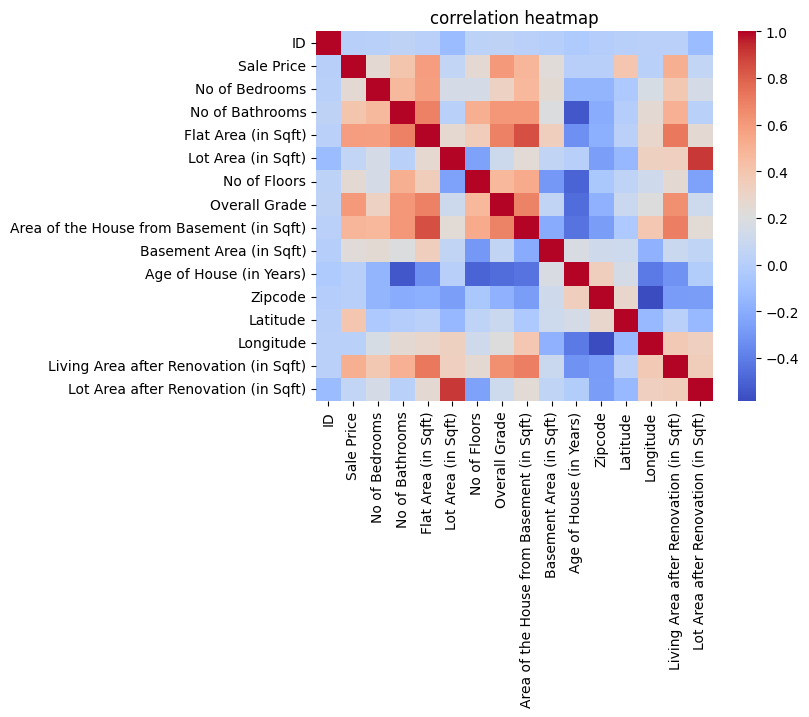

In [330]:
# ploting a heat map to visualize correlation
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

In [331]:
# From the map, ID has the lowest correlation with other features, hence removing ID
housing_df.drop('ID', axis=1, inplace=True)
housing_df.head(2)

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,7.0,1180.0,0,63,98178.0,47.5112,-122.257,1340.0,5650.0
1,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,7.0,2170.0,400,67,98125.0,47.7210,-122.319,1690.0,7639.0


In [332]:
numerical_cols.remove("ID")

## Scaling

In [333]:
# min- max scaler (used when data distribution is skewed)

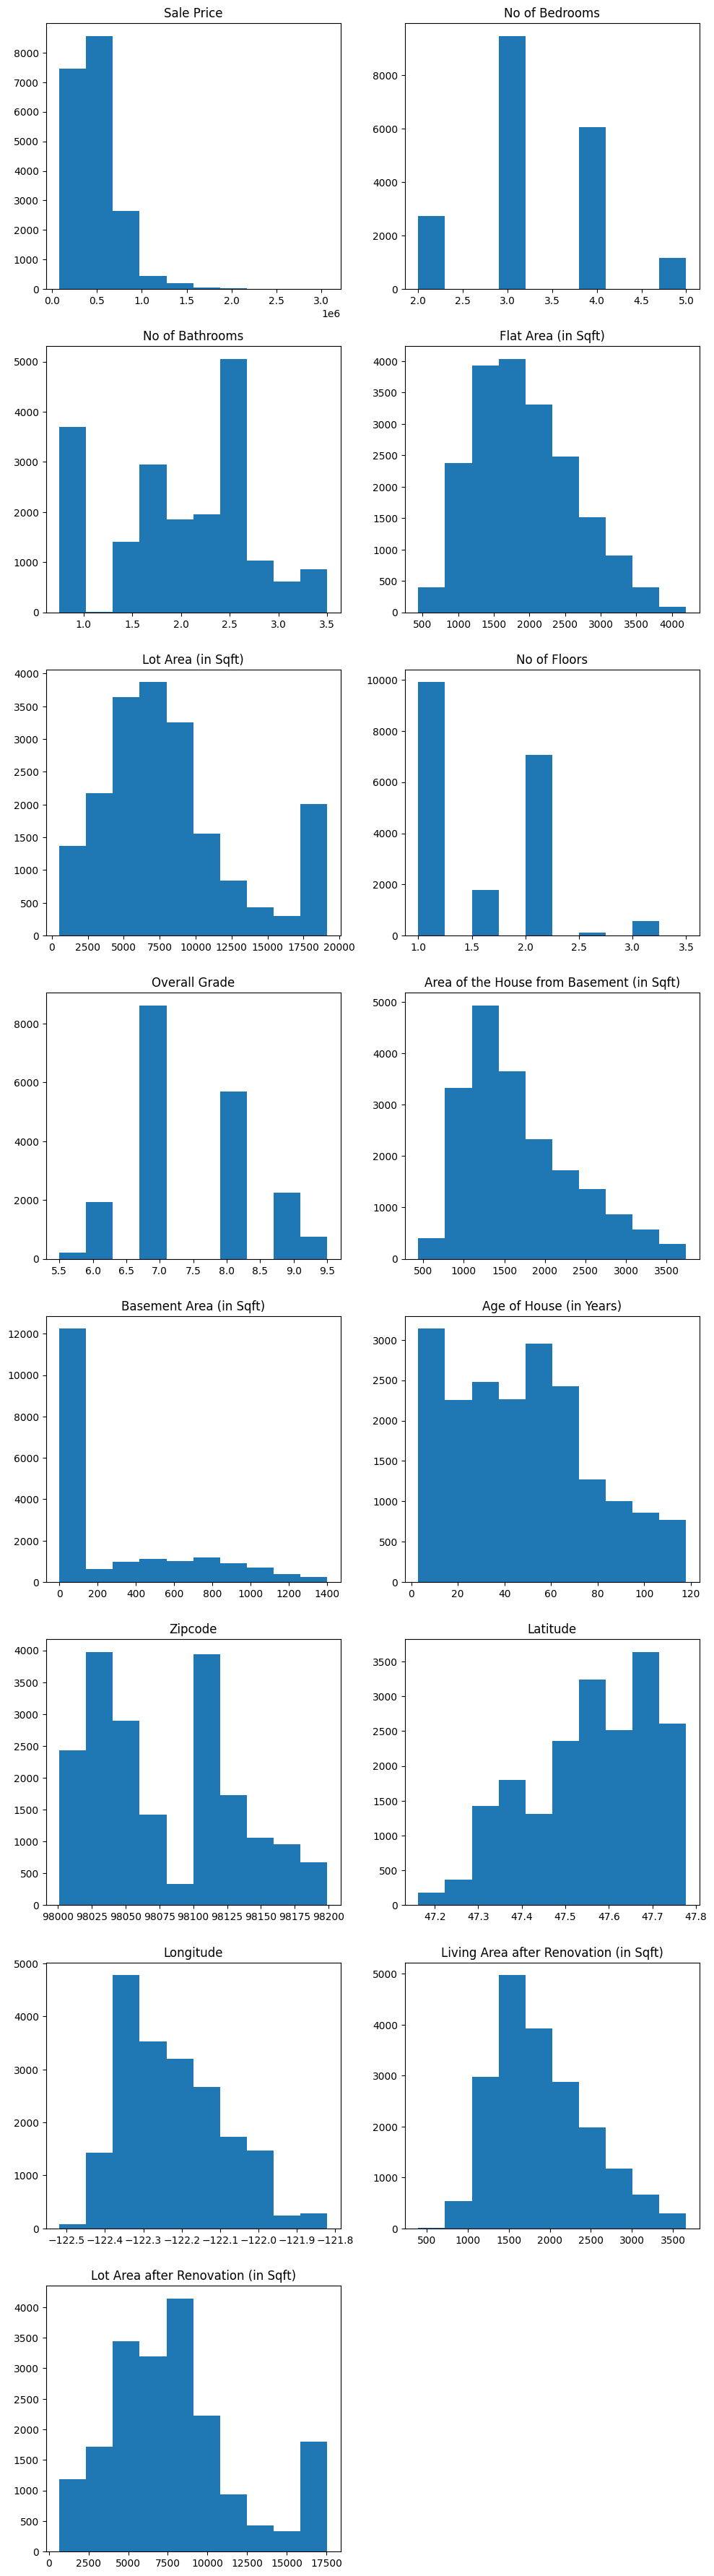

In [334]:
plt.figure(figsize = (10, 40))
for i, col in enumerate(numerical_cols,1):
  plt.subplot(9,2,i)
  plt.hist(housing_df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

In [335]:
numerical_cols

['Sale Price',
 'No of Bedrooms',
 'No of Bathrooms',
 'Flat Area (in Sqft)',
 'Lot Area (in Sqft)',
 'No of Floors',
 'Overall Grade',
 'Area of the House from Basement (in Sqft)',
 'Basement Area (in Sqft)',
 'Age of House (in Years)',
 'Zipcode',
 'Latitude',
 'Longitude',
 'Living Area after Renovation (in Sqft)',
 'Lot Area after Renovation (in Sqft)']

In [336]:
housing_df.describe()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,1.942700e+04,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000
mean,4.876620e+05,3.292582,2.022263,1929.445411,8290.770217,1.477248,7.504195,1676.574922,252.953724,47.681989,98079.390590,47.558171,-122.222670,1899.710094,7951.615072
std,2.473135e+05,0.780006,0.661564,690.790099,4815.122235,0.539324,0.928209,663.841464,376.374594,29.303992,53.663534,0.141462,0.130499,571.803753,4166.674890
min,7.800000e+04,2.000000,0.750000,440.000000,520.000000,1.000000,5.500000,440.000000,0.000000,3.000000,98001.000000,47.162200,-122.519000,399.000000,651.000000
25%,3.150000e+05,3.000000,1.500000,1400.000000,5000.000000,1.000000,7.000000,1170.000000,0.000000,23.000000,98033.000000,47.459900,-122.332000,1470.000000,5000.000000
50%,4.350000e+05,3.000000,2.000000,1840.000000,7392.000000,1.000000,7.000000,1510.000000,0.000000,45.000000,98072.000000,47.570700,-122.244000,1800.000000,7480.000000
75%,6.000000e+05,4.000000,2.500000,2390.000000,10030.500000,2.000000,8.000000,2070.000000,500.000000,67.000000,98118.000000,47.680050,-122.134000,2260.000000,9685.000000
max,3.070000e+06,5.000000,3.500000,4200.000000,19152.500000,3.500000,9.500000,3740.000000,1400.000000,118.000000,98199.000000,47.777600,-121.821000,3660.000000,17557.500000


In [337]:
min_max_scaler = MinMaxScaler()
housing_df[['No of Bedrooms',
 'No of Bathrooms',
 'Flat Area (in Sqft)',
 'Lot Area (in Sqft)',
 'No of Floors',
 'Overall Grade',
 'Area of the House from Basement (in Sqft)',
 'Basement Area (in Sqft)',
 'Age of House (in Years)',
 'Zipcode',
 'Latitude',
 'Longitude',
 'Living Area after Renovation (in Sqft)',
 'Lot Area after Renovation (in Sqft)']] = min_max_scaler.fit_transform(housing_df[['No of Bedrooms',
 'No of Bathrooms',
 'Flat Area (in Sqft)',
 'Lot Area (in Sqft)',
 'No of Floors',
 'Overall Grade',
 'Area of the House from Basement (in Sqft)',
 'Basement Area (in Sqft)',
 'Age of House (in Years)',
 'Zipcode',
 'Latitude',
 'Longitude',
 'Living Area after Renovation (in Sqft)',
 'Lot Area after Renovation (in Sqft)']])

In [338]:
housing_df.describe()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,1.942700e+04,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000
mean,4.876620e+05,0.430861,0.462641,0.396129,0.417055,0.190899,0.501049,0.374720,0.180681,0.388539,0.395912,0.643437,0.424542,0.460199,0.431823
std,2.473135e+05,0.260002,0.240569,0.183721,0.258426,0.215730,0.232052,0.201164,0.268839,0.254817,0.271028,0.229870,0.186961,0.175346,0.246454
min,7.800000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.150000e+05,0.333333,0.272727,0.255319,0.240440,0.000000,0.375000,0.221212,0.000000,0.173913,0.161616,0.483750,0.267908,0.328427,0.257238
50%,4.350000e+05,0.333333,0.454545,0.372340,0.368818,0.000000,0.375000,0.324242,0.000000,0.365217,0.358586,0.663796,0.393983,0.429623,0.403927
75%,6.000000e+05,0.666667,0.636364,0.518617,0.510425,0.400000,0.625000,0.493939,0.357143,0.556522,0.590909,0.841485,0.551576,0.570684,0.534351
max,3.070000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [339]:
# correlation after scaling
corr_matrix = housing_df[['No of Bedrooms',
 'No of Bathrooms',
 'Flat Area (in Sqft)',
 'Lot Area (in Sqft)',
 'No of Floors',
 'Overall Grade',
 'Area of the House from Basement (in Sqft)',
 'Basement Area (in Sqft)',
 'Age of House (in Years)',
 'Zipcode',
 'Latitude',
 'Longitude',
 'Living Area after Renovation (in Sqft)',
 'Lot Area after Renovation (in Sqft)']].corr(method='pearson')
corr_matrix

,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
No of Bedrooms,1.000000,0.463445,0.583948,0.156361,0.155202,0.316799,0.468327,0.246330,-0.158798,-0.161464,-0.042764,0.168984,0.385658,0.153332
No of Bathrooms,0.463445,1.000000,0.693427,0.013553,0.514971,0.613315,0.610208,0.196890,-0.546980,-0.204413,-0.007343,0.253799,0.508089,0.013974
Flat Area (in Sqft),0.583948,0.693427,1.000000,0.262477,0.349818,0.693457,0.845968,0.343215,-0.328076,-0.194484,0.020672,0.278508,0.726924,0.255454
Lot Area (in Sqft),0.156361,0.013553,0.262477,1.000000,-0.253882,0.109513,0.243434,0.053024,0.007652,-0.266297,-0.140236,0.329919,0.331800,0.907658
No of Floors,0.155202,0.514971,0.349818,-0.253882,1.000000,0.469123,0.531009,-0.294279,-0.498318,-0.052292,0.041612,0.122651,0.254150,-0.256432
Overall Grade,0.316799,0.613315,0.693457,0.109513,0.469123,1.000000,0.690333,0.056039,-0.466886,-0.170360,0.100491,0.209709,0.645637,0.119744
Area of the House from Basement (in Sqft),0.468327,0.610208,0.845968,0.243434,0.531009,0.690333,1.000000,-0.209854,-0.442731,-0.271089,-0.043976,0.390757,0.699477,0.239159
Basement Area (in Sqft),0.246330,0.196890,0.343215,0.053024,-0.294279,0.056039,-0.209854,1.000000,0.178700,0.121075,0.115672,-0.177747,0.101599,0.047723
Age of House (in Years),-0.158798,-0.546980,-0.328076,0.007652,-0.498318,-0.466886,-0.442731,0.178700,1.000000,0.339565,0.156771,-0.417935,-0.321021,-0.012274
Zipcode,-0.161464,-0.204413,-0.194484,-0.266297,-0.052292,-0.170360,-0.271089,0.121075,0.339565,1.000000,0.278474,-0.585187,-0.280026,-0.274734


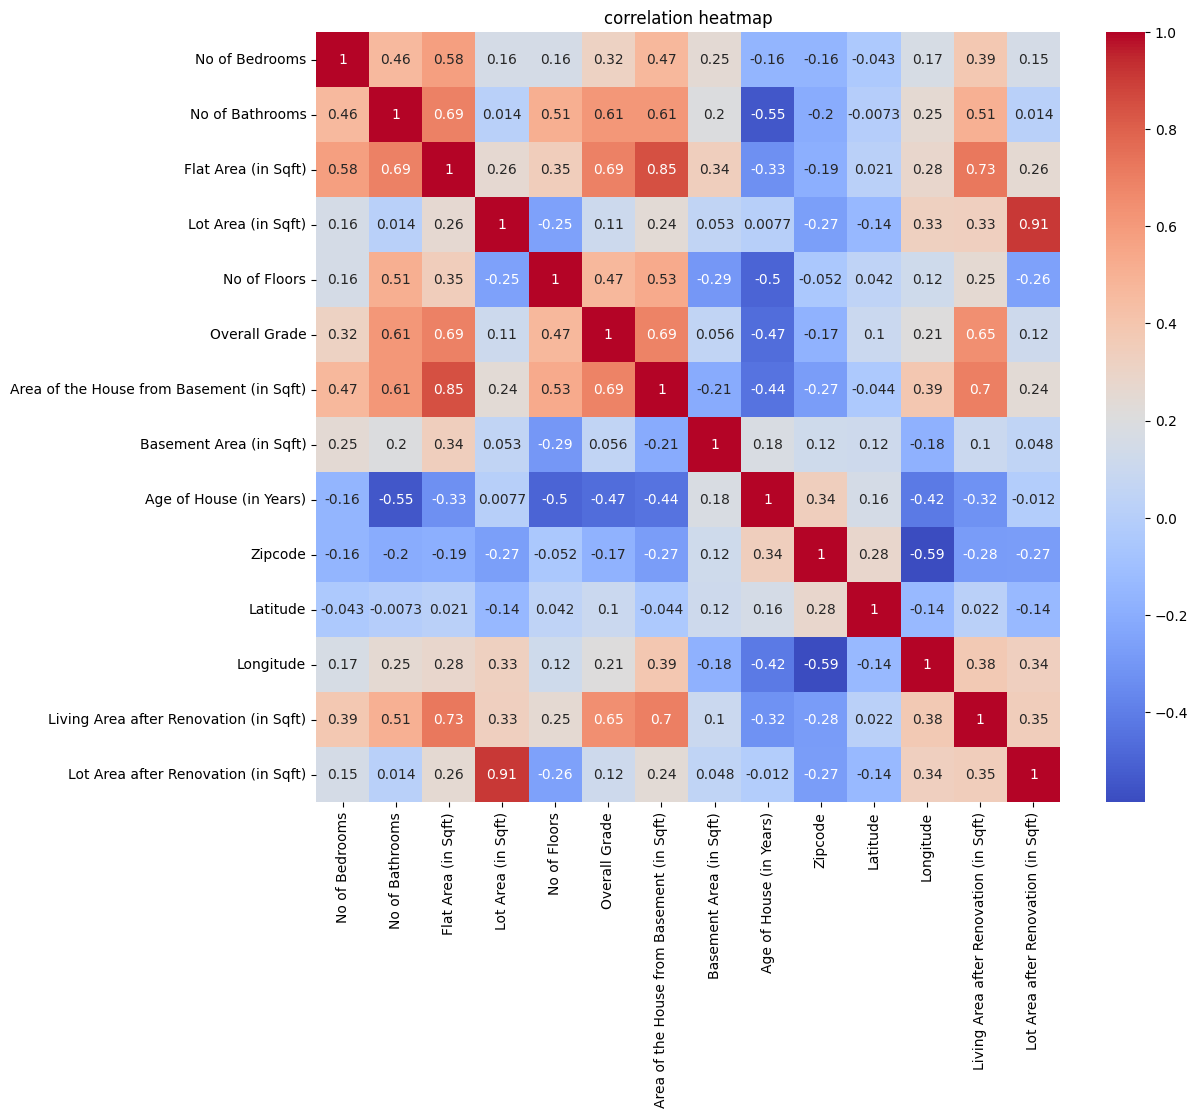

In [340]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

## Encoding

In [343]:
cat_cols = cat_cols.drop('No of Times Visited')

In [344]:
housing_df[cat_cols].head(5)

,Date House was Sold,Waterfront View,Condition of the House
0,14 October 2017,No,Fair
1,14 December 2017,No,Fair
2,15 February 2016,No,Fair
3,14 December 2017,No,Excellent
4,15 February 2016,No,Fair


In [346]:
housing_df[cat_cols].head(5)

,Date House was Sold,Waterfront View,Condition of the House
0,14 October 2017,No,Fair
1,14 December 2017,No,Fair
2,15 February 2016,No,Fair
3,14 December 2017,No,Excellent
4,15 February 2016,No,Fair


In [347]:
housing_df['Condition of the House'].unique()

array(['Fair', 'Excellent', 'Good', 'Bad', 'Okay'], dtype=object)

In [348]:
label_encoder = LabelEncoder()

housing_df['Condition of the House'] = label_encoder.fit_transform(housing_df['Condition of the House'])
housing_df['Waterfront View'] = label_encoder.fit_transform(housing_df['Waterfront View'])

In [349]:
housing_df.head()

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,0.333333,0.090909,0.196809,0.275325,0.0,0,2,0.375,0.224242,0.000000,0.521739,0.893939,0.567111,0.375358,0.288562,0.295685
1,14 December 2017,538000.0,0.333333,0.545455,0.566489,0.360767,0.4,0,2,0.375,0.524242,0.285714,0.556522,0.626263,0.908027,0.286533,0.395891,0.413332
2,15 February 2016,180000.0,0.000000,0.090909,0.087766,0.508788,0.0,0,2,0.125,0.100000,0.000000,0.713043,0.136364,0.935489,0.409742,0.711745,0.438352
3,14 December 2017,604000.0,0.666667,0.818182,0.404255,0.240440,0.0,0,1,0.375,0.184848,0.650000,0.434783,0.681818,0.582710,0.180516,0.294695,0.257238
4,15 February 2016,510000.0,0.333333,0.454545,0.329787,0.405743,0.0,0,2,0.625,0.375758,0.000000,0.243478,0.368687,0.738707,0.679083,0.429623,0.405288


In [351]:
# Separating features and target
X = housing_df.drop('Sale Price', axis=1)
y = housing_df['Sale Price']

# Train-test splitting (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

In [352]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(15541, 17) (3886, 17)
(15541,) (3886,)
